<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/MEG_HES008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running QFT2004i1 (λ, k0) scan...
λ = 0.000, k0 = 0.000 | C_final = 1.0000, width_final = 0.8522, peak_final = 0.9958
λ = 0.000, k0 = 0.250 | C_final = 1.0000, width_final = 0.8154, peak_final = 0.9950
λ = 0.000, k0 = 0.500 | C_final = 1.0000, width_final = 0.7178, peak_final = 0.9926
λ = 0.000, k0 = 0.750 | C_final = 0.9999, width_final = 0.6097, peak_final = 0.9883
λ = 0.000, k0 = 1.000 | C_final = 0.9998, width_final = 0.5807, peak_final = 0.9813
λ = 0.000, k0 = 1.250 | C_final = 0.9996, width_final = 0.6574, peak_final = 0.9711
λ = 0.000, k0 = 1.500 | C_final = 0.9992, width_final = 0.7599, peak_final = 0.9567
λ = 0.000, k0 = 1.750 | C_final = 0.9985, width_final = 0.8329, peak_final = 0.9371
λ = 0.000, k0 = 2.000 | C_final = 0.9972, width_final = 0.8732, peak_final = 0.9116
λ = 0.000, k0 = 2.250 | C_final = 0.9953, width_final = 0.8945, peak_final = 0.8791
λ = 0.000, k0 = 2.500 | C_final = 0.9923, width_final = 0.9080, peak_final = 0.8394
λ = 0.000, k0 = 2.750 | C_final = 0.9878, 

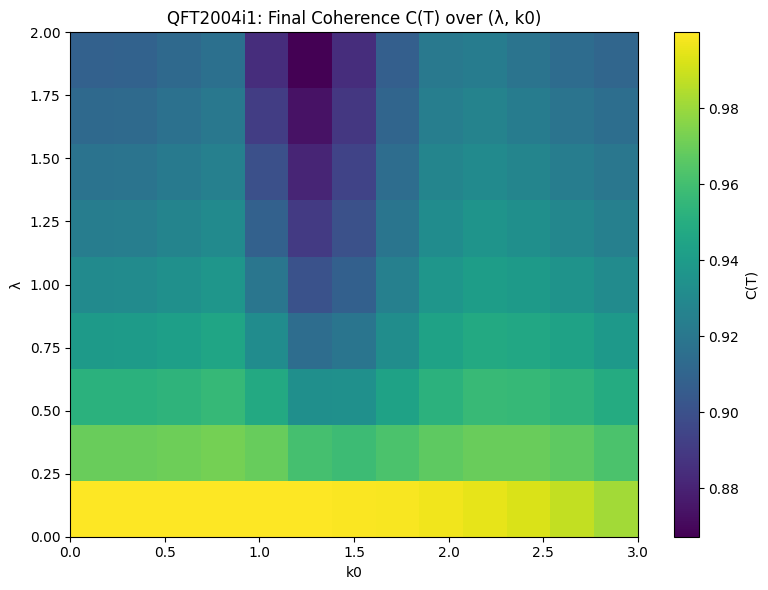

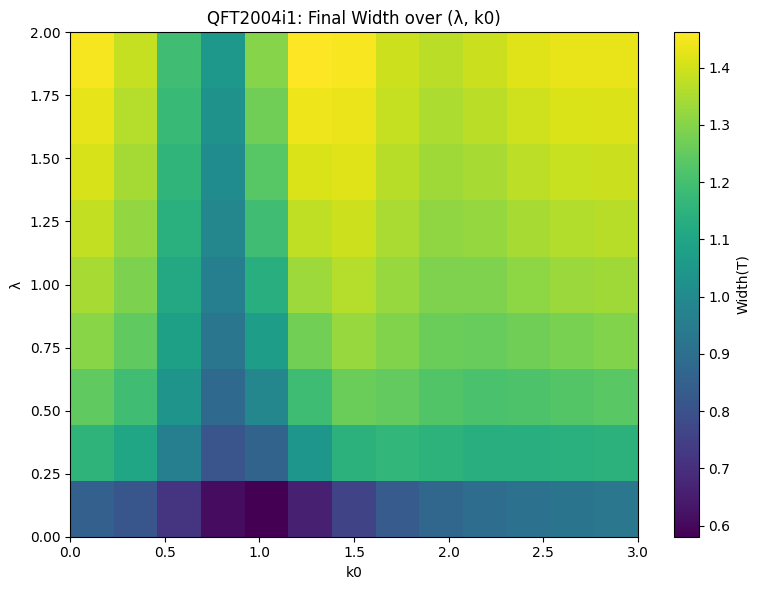

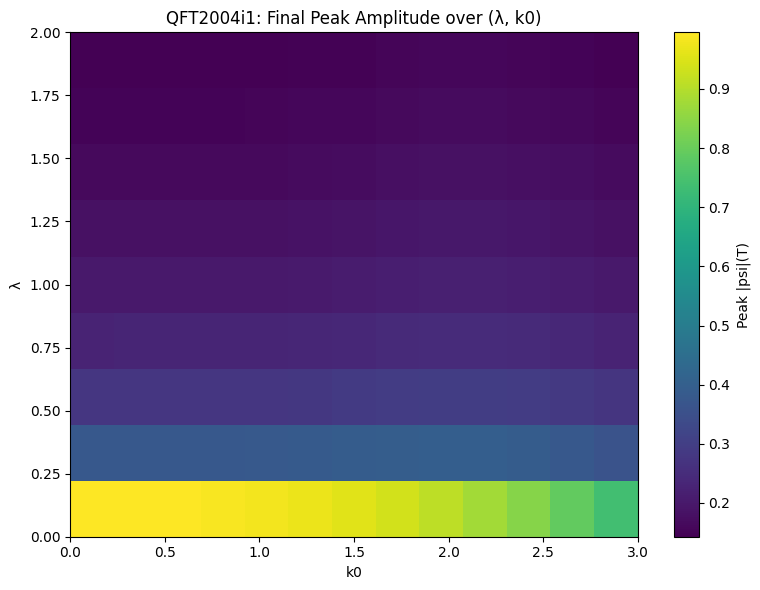


QFT2004i1 summary (extremes):
  C_min = 0.8672, C_max = 1.0000
  width_min = 0.5807, width_max = 1.4619
  peak_min = 0.1428, peak_max = 0.9958


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004i1 — 2D Shape-Memory Map in (λ, k0)
# ============================================================

# --- Lattice parameters ---
N = 512
L = 50.0
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

# --- Time parameters ---
dt = 0.002
steps = 6000
t_final = steps * dt

# --- Physical parameters (fixed except λ, k0) ---
m = 1.0
A = 1.0
sigma = 1.2

# --- Precompute FFT wave numbers ---
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# --- Helper functions ---
def compute_width(field):
    norm = np.sum(field**2)
    mean = np.sum(x * field**2) / norm
    var = np.sum((x - mean)**2 * field**2) / norm
    return np.sqrt(var)

def compute_coherence(field, ref):
    num = np.abs(np.sum(field * ref))
    den = np.sqrt(np.sum(field**2) * np.sum(ref**2))
    return num / den

def evolve_and_measure(lam, k0, steps=steps, dt=dt):
    """
    For given (λ, k0):
      - build psi0(x; k0)
      - evolve under λ
      - return final coherence with psi0, width, peak amplitude
    """
    psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)
    psi = psi0.copy()

    for step in range(steps):
        # Nonlinear step
        psi_nl = psi - dt * lam * psi**3

        # Linear step via FFT
        psi_k = np.fft.fft(psi_nl)
        psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
        psi = np.real(np.fft.ifft(psi_k))

    C_final = compute_coherence(psi, psi0)
    width_final = compute_width(psi)
    peak_final = np.max(np.abs(psi))
    return C_final, width_final, peak_final

# ============================================================
# Parameter grids
# ============================================================

lambda_values = np.linspace(0.0, 2.0, 9)      # 0.0 ... 2.0
k0_values     = np.linspace(0.0, 3.0, 13)     # 0.0 ... 3.0

n_lam = len(lambda_values)
n_k0  = len(k0_values)

C_map     = np.zeros((n_lam, n_k0))
width_map = np.zeros((n_lam, n_k0))
peak_map  = np.zeros((n_lam, n_k0))

print("Running QFT2004i1 (λ, k0) scan...")
for i, lam in enumerate(lambda_values):
    for j, k0 in enumerate(k0_values):
        C_final, w_final, p_final = evolve_and_measure(lam, k0)
        C_map[i, j]     = C_final
        width_map[i, j] = w_final
        peak_map[i, j]  = p_final
        print(f"λ = {lam:.3f}, k0 = {k0:.3f} | C_final = {C_final:.4f}, width_final = {w_final:.4f}, peak_final = {p_final:.4f}")

# ============================================================
# Plotting: heatmaps over (λ, k0)
# ============================================================

Lambda, K0 = np.meshgrid(k0_values, lambda_values)  # note: x=k0, y=λ for plotting

def plot_heatmap(data, title, cbar_label):
    plt.figure(figsize=(8,6))
    im = plt.imshow(
        data,
        origin='lower',
        aspect='auto',
        extent=[k0_values[0], k0_values[-1], lambda_values[0], lambda_values[-1]]
    )
    plt.colorbar(im, label=cbar_label)
    plt.xlabel("k0")
    plt.ylabel("λ")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(C_map,     "QFT2004i1: Final Coherence C(T) over (λ, k0)", "C(T)")
plot_heatmap(width_map, "QFT2004i1: Final Width over (λ, k0)",          "Width(T)")
plot_heatmap(peak_map,  "QFT2004i1: Final Peak Amplitude over (λ, k0)", "Peak |psi|(T)")

# ============================================================
# Brief printed summary (extremes)
# ============================================================
print("\nQFT2004i1 summary (extremes):")
print(f"  C_min = {C_map.min():.4f}, C_max = {C_map.max():.4f}")
print(f"  width_min = {width_map.min():.4f}, width_max = {width_map.max():.4f}")
print(f"  peak_min = {peak_map.min():.4f}, peak_max = {peak_map.max():.4f}")


In [ ]:
# ============================================================
# Helper: evolve and return final field ψ(x; λ, k0)
# ============================================================

def evolve_return_field(lam, k0, steps=steps, dt=dt):
    psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)
    psi = psi0.copy()

    for step in range(steps):
        # Nonlinear step
        psi_nl = psi - dt * lam * psi**3

        # Linear step via FFT
        psi_k = np.fft.fft(psi_nl)
        psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
        psi = np.real(np.fft.ifft(psi_k))

    return psi0, psi


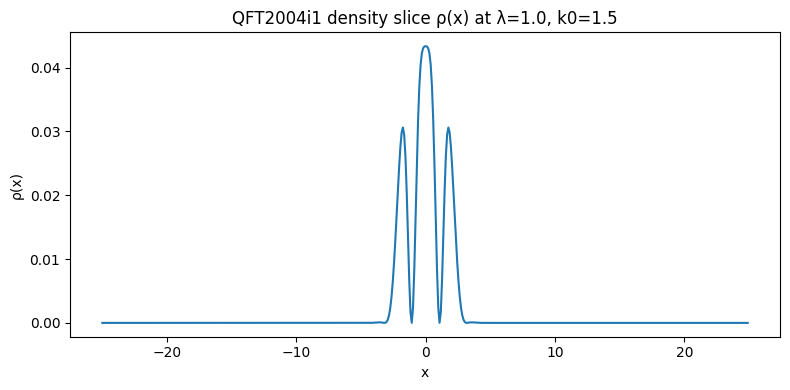

In [ ]:
# ============================================================
# Choose a (λ, k0) point and build a density ρ(x)
# ============================================================

lam_target = 1.0   # choose any λ from your grid or beyond
k0_target  = 1.5   # choose any k0

psi0_target, psi_final_target = evolve_return_field(lam_target, k0_target)

# Define "density" for HES as |ψ|^2
rho = psi_final_target**2

plt.figure(figsize=(8,4))
plt.plot(x, rho)
plt.title(f"QFT2004i1 density slice ρ(x) at λ={lam_target}, k0={k0_target}")
plt.xlabel("x")
plt.ylabel("ρ(x)")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# MEG‑HES008_REAL — Temporal–Geometric Cross‑Calibration on QFT2004i1 ρ(x)
# ============================================================

# ρ is already defined from previous cell, shape (N,)
assert rho.ndim == 1
N = rho.shape[0]

# Optional: light smoothing to match HES coherence
rho_smooth = gaussian_filter1d(rho, sigma=3)

# Normalize
rho_smooth = rho_smooth / np.mean(rho_smooth)

# 1. Entanglement density
rho_ent = np.tanh(0.9 * (rho_smooth - 1.0))

# 2. Curvature compensation load
gamma = 0.55
C = np.sign(rho_ent) * (np.abs(rho_ent) ** gamma)

# 3. Update-rate field and temporal drift
f = 1.0 / (1.0 + np.abs(C))
dz = np.gradient(f, x)

# 4. Geometric curvature proxy
K = np.gradient(C, x)

# 5. Cross-calibration: Δz ~ K^α
eps = 1e-12
mask = (np.abs(K) > eps) & (np.abs(dz) > eps)
logK = np.log(np.abs(K[mask]))
logdz = np.log(np.abs(dz[mask]))

A = np.vstack([logK, np.ones_like(logK)]).T
alpha_fit, logA_fit = np.linalg.lstsq(A, logdz, rcond=None)[0]
A_fit = np.exp(logA_fit)

print("====================================================")
print("MEG‑HES008_REAL — Temporal–Geometric Cross‑Calibration")
print("====================================================")
print(f"Fitted exponent α (Δz ∝ K^α): {alpha_fit:.4f}")
print(f"Prefactor A: {A_fit:.4e}")
print("====================================================")


MEG‑HES008_REAL — Temporal–Geometric Cross‑Calibration
Fitted exponent α (Δz ∝ K^α): 0.9950
Prefactor A: 2.6034e-01


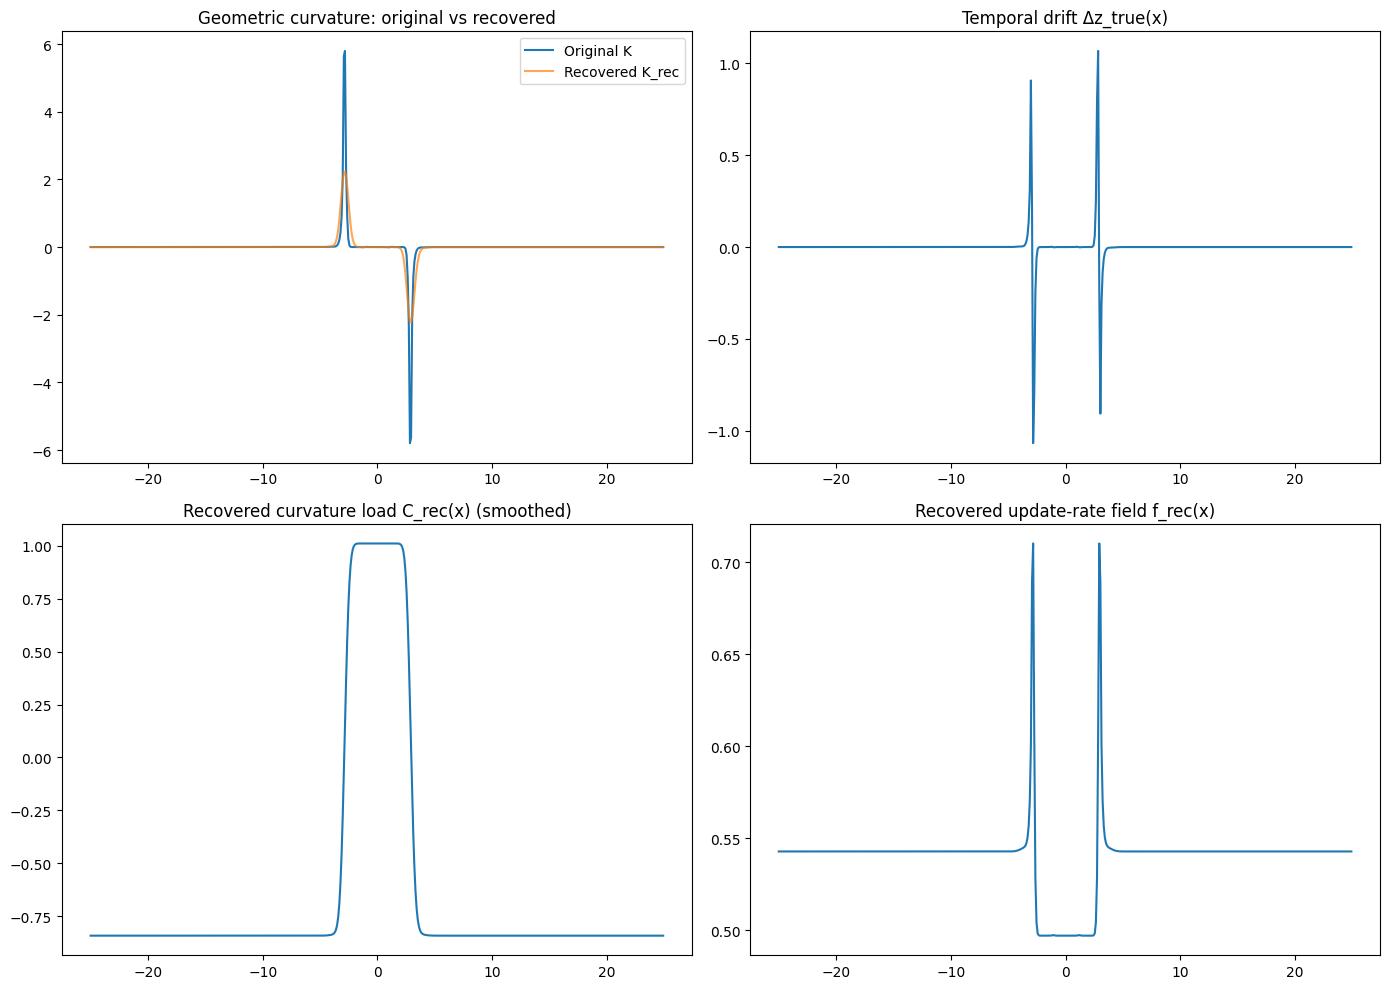

MEG‑HES008_REAL — Tightened Inverse
Closure error (K vs K_rec): 6.2461e-01


In [ ]:
from scipy.ndimage import gaussian_filter1d

# ============================================================
# MEG‑HES008b_REAL — Tightened Inverse on QFT2004i1 ρ(x)
# ============================================================

dx = x[1] - x[0]
dz_true = dz.copy()  # from 005_REAL

# Inverse: integrate dz to recover f_rec
dz_centered = dz_true - np.mean(dz_true)

f_rec = np.zeros_like(dz_centered)
f_rec[0] = np.mean(f)
for i in range(1, N):
    f_rec[i] = f_rec[i-1] + dz_centered[i-1] * dx

f_min = 1e-3
f_rec = np.clip(f_rec, f_min, None)

# Recover curvature load
C_abs_rec = (1.0 / f_rec) - 1.0
C_abs_rec = np.maximum(C_abs_rec, 0.0)

sign_C = np.sign(C)
C_rec = sign_C * C_abs_rec

# Tightening: smooth C_rec
C_rec = gaussian_filter1d(C_rec, sigma=3)

# Recovered curvature
K_rec = np.gradient(C_rec, x)

# Closure metric
mask = np.isfinite(K) & np.isfinite(K_rec)
num = np.linalg.norm(K[mask] - K_rec[mask])
den = np.linalg.norm(K[mask]) + 1e-12
closure_error = num / den

plt.figure(figsize=(14, 10))

plt.subplot(2,2,1)
plt.plot(x, K, label="Original K")
plt.plot(x, K_rec, label="Recovered K_rec", alpha=0.7)
plt.title("Geometric curvature: original vs recovered")
plt.legend()

plt.subplot(2,2,2)
plt.plot(x, dz_true)
plt.title("Temporal drift Δz_true(x)")

plt.subplot(2,2,3)
plt.plot(x, C_rec)
plt.title("Recovered curvature load C_rec(x) (smoothed)")

plt.subplot(2,2,4)
plt.plot(x, f_rec)
plt.title("Recovered update-rate field f_rec(x)")

plt.tight_layout()
plt.show()

print("====================================================")
print("MEG‑HES008_REAL — Tightened Inverse")
print("====================================================")
print(f"Closure error (K vs K_rec): {closure_error:.4e}")
print("====================================================")
